
# 🔍 EDA - Dataset Validation

Este notebook valida o dataset processado (`dataset.csv`) antes de modelagem.

Objetivos:
- Verificar qualidade dos dados
- Detectar problemas (duplicados, textos vazios)
- Validar distribuição e consistência


In [1]:

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-darkgrid")


In [2]:

df = pd.read_csv("../data/processed/dataset.csv")
df.head()


,id,text,label
0,002-0.cha,the scene is in the kitchen the mother is wipi...,0
1,002-1.cha,oh i see the sink is running over i see the st...,0
2,002-2.cha,um a boy and a girl are in the kitchen with th...,0
3,002-3.cha,okay it was summertime and mother and the chil...,0
4,006-2.cha,clears throat wait un til i put my glasses on ...,0


## 📦 Informações gerais

In [3]:

df.info()
df.describe(include='all')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      545 non-null    object
 1   text    545 non-null    object
 2   label   545 non-null    int64 
dtypes: int64(1), object(2)
memory usage: 12.9+ KB


,id,text,label
count,545,545,545.000000
unique,545,544,NaN
top,002-0.cha,okay um you mean drying dishes uh overflowing ...,NaN
freq,1,2,NaN
mean,NaN,NaN,0.557798
std,NaN,NaN,0.497104
min,NaN,NaN,0.000000
25%,NaN,NaN,0.000000
50%,NaN,NaN,1.000000
75%,NaN,NaN,1.000000


## 🔁 Duplicados

In [4]:

print("Duplicados (linhas):", df.duplicated().sum())
print("Duplicados (texto):", df['text'].duplicated().sum())


Duplicados (linhas): 0
Duplicados (texto): 1


## 📏 Tamanho do texto

In [5]:

df['text_length'] = df['text'].apply(len)
df['text_length'].describe()


count     545.000000
mean      497.919266
std       263.325350
min        58.000000
25%       316.000000
50%       450.000000
75%       598.000000
max      2480.000000
Name: text_length, dtype: float64

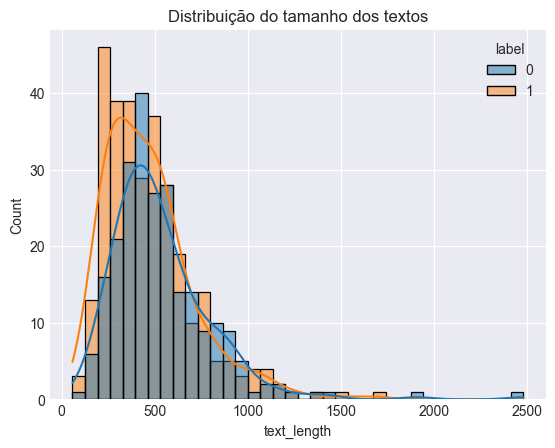

In [6]:

sns.histplot(data=df, x='text_length', hue='label', kde=True)
plt.title("Distribuição do tamanho dos textos")
plt.show()


## ⚠️ Textos muito curtos

In [7]:

df[df['text_length'] < 20].head()


,id,text,label,text_length


## ⚖️ Distribuição das classes

In [8]:

df['label'].value_counts()


label
1    304
0    241
Name: count, dtype: int64

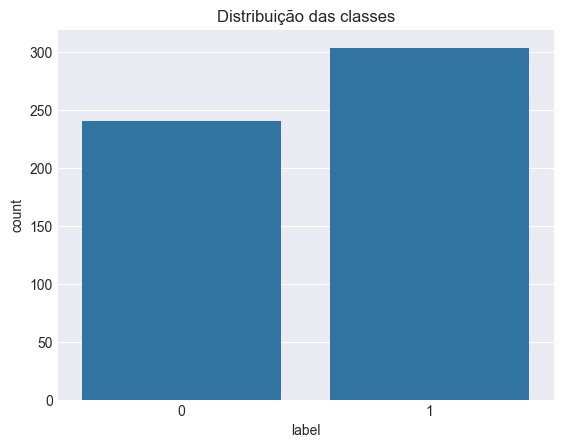

In [9]:

sns.countplot(data=df, x='label')
plt.title("Distribuição das classes")
plt.show()


## 🧠 Exemplos reais

In [10]:

print("CONTROL:")
print(df[df['label']==0]['text'].sample(2).values)

print("\nDEMENTIA:")
print(df[df['label']==1]['text'].sample(2).values)


CONTROL:
['the uh water s running on the floor boy s taking cookie out of the cookie jar the stool is falling open over the girl was asking for a cookie the wife is wiping a dish plate i guess not'
 'clears throat uh the water s runnin g over the mother s dryin g dishes the boy is stealin g cookies and the girl is takin g one and the boy is gonna fall off the stool and uh the water is running and the window s open and the grass is growing it s all the action curtain']

DEMENTIA:
['he must be pickin g apples here be cause he s on the ladder and he s got both hands open and he can be and the chair was fallin g the baby s cryin g that s all'
 'yeah she s spilling the water on the floor and he s falling off the a seat or the spigot s goin g and uh he s reaching out for the cookies and she s reaching for the cookies and she got the window open i guess i don t know']


## 🔤 Frequência de palavras

In [11]:

from collections import Counter

all_words = " ".join(df['text']).split()
Counter(all_words).most_common(20)


[('the', 5551),
 ('s', 3223),
 ('and', 2467),
 ('is', 1810),
 ('a', 1484),
 ('uh', 1363),
 ('g', 991),
 ('she', 985),
 ('i', 978),
 ('to', 911),
 ('that', 891),
 ('on', 858),
 ('cookie', 829),
 ('it', 779),
 ('in', 701),
 ('water', 698),
 ('he', 682),
 ('there', 642),
 ('dishes', 604),
 ('over', 570)]

## ⚠️ Tokens estranhos

In [12]:

import re

def find_weird(text):
    return re.findall(r'[^a-zA-Z\s]', text)

df['weird_tokens'] = df['text'].apply(find_weird)
df['weird_tokens'].apply(len).describe()


count    545.0
mean       0.0
std        0.0
min        0.0
25%        0.0
50%        0.0
75%        0.0
max        0.0
Name: weird_tokens, dtype: float64

## 🔗 Correlação (features básicas)

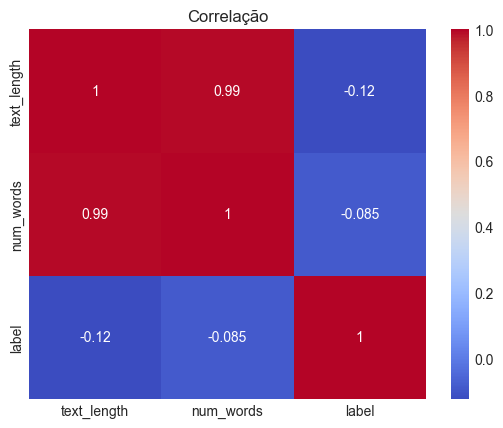

In [13]:

df['num_words'] = df['text'].apply(lambda x: len(x.split()))

corr = df[['text_length','num_words','label']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlação")
plt.show()



## ✅ Conclusão

Checklist:
- [ ] Dados sem duplicados
- [ ] Textos com tamanho consistente
- [ ] Classes balanceadas
- [ ] Sem ruído excessivo

Se tudo OK → pronto para modelagem (BoW / TF-IDF)


Conclusão — Validação do Dataset

O dataset processado apresenta boa qualidade geral e está adequado para etapas de modelagem.

Integridade dos dados: não há valores nulos nas colunas principais (text, label).

Duplicação: inexistente em nível de linhas e praticamente irrelevante em nível de texto.

Distribuição das classes: levemente desbalanceada (≈56% dementia vs 44% control), mas ainda aceitável para modelos básicos.

Tamanho dos textos: distribuição consistente, com poucos outliers longos e sem textos extremamente curtos.

Ruído textual: ausência de tokens estranhos indica que o pré-processamento foi eficaz.

Correlação: features básicas (tamanho do texto e número de palavras) têm baixa correlação com o label, sugerindo que:
👉 o problema não é trivial
👉 modelos simples baseados apenas em tamanho não serão suficientes